# 01. EDA

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

## 1. Load Dataset

In [2]:
# Import the dataset
# df_news_final_project = pd.read_parquet('https://storage.googleapis.com/msca-bdp-data-open/news_final_project/news_final_project.parquet', engine='pyarrow')
df_news_final_project = pd.read_parquet(
    'data/news_final_project.parquet',
    engine='pyarrow')
df_news_final_project.shape

(199989, 5)

## 2. Basic Structure and Field Inspection

In [3]:
df = df_news_final_project.copy()

print(df.shape)
print(df.columns)

df.head(3)

(199989, 5)
Index(['url', 'date', 'language', 'title', 'text'], dtype='object')


,url,date,language,title,text
0,https://blockworks.co/price/bad,2025-06-23,en,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod..."
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,en,This AI video of gymnastics might be the freak...,\n\nThis AI video of gymnastics might be the f...
2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,en,"If using AI feels like a chore, try this - Boi...","\n\nIf using AI feels like a chore, try this -..."


In [4]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199989 entries, 0 to 199988
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   url       199989 non-null  object
 1   date      199989 non-null  object
 2   language  199989 non-null  object
 3   title     199989 non-null  object
 4   text      199989 non-null  object
dtypes: object(5)
memory usage: 3.6 GB


## 3. Missing Values and Basic Quality Metrics

In [5]:
na = df.isna().sum().sort_values(ascending=False)
na_ratio = (na / len(df)).round(4)

pd.DataFrame({
    "na_cnt": na,
    "na_ratio": na_ratio
})

,na_cnt,na_ratio
url,0,0.0
date,0,0.0
language,0,0.0
title,0,0.0
text,0,0.0


## 4. Deduplication and Uniqueness (URL)

In [6]:
dup_url_rows = df["url"].duplicated(keep=False).sum()
dup_url_ratio = df["url"].duplicated().mean()
url_unique_ratio = df["url"].nunique() / len(df)

print("dup_url_rows:", dup_url_rows)
print("dup_url_ratio:", dup_url_ratio)
print("url_unique_ratio:", url_unique_ratio)

dup_url_rows: 0
dup_url_ratio: 0.0
url_unique_ratio: 1.0


## 5. Exact Text Duplicate Estimate

In [7]:
text_hash = pd.util.hash_pandas_object(df["text"].fillna(""), index=False)
dup_text_exact_ratio = text_hash.duplicated().mean()

print("dup_text_exact_ratio:", dup_text_exact_ratio)

dup_text_exact_ratio: 0.002470135857472161


## 6. Time Field Parsing and Monthly Statistics

In [8]:
dt = pd.to_datetime(df["date"], errors="coerce", utc=True)

print("parsed_na:", dt.isna().mean())
print("min:", dt.min(), "max:", dt.max())

df = df.assign(
    dt=dt,
    ym=dt.dt.to_period("M")
)

parsed_na: 0.0
min: 2022-01-01 00:00:00+00:00 max: 2026-02-10 00:00:00+00:00


/var/folders/_f/hqh752t53tg1jmq2wwf1m7jh0000gn/T/ipykernel_70820/324636135.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  ym=dt.dt.to_period("M")


In [9]:
monthly = df.groupby("ym").size().sort_index()

display(monthly.head())
display(monthly.tail())
display(monthly.describe())

ym
2022-01    1140
2022-02    1118
2022-03    1114
2022-04     937
2022-05    1468
Freq: M, dtype: int64

ym
2025-10    5461
2025-11    5096
2025-12    5573
2026-01    4583
2026-02    1528
Freq: M, dtype: int64

count      50.000000
mean     3999.780000
std      1972.355696
min       937.000000
25%      2284.500000
50%      3687.000000
75%      5246.000000
max      8246.000000
dtype: float64

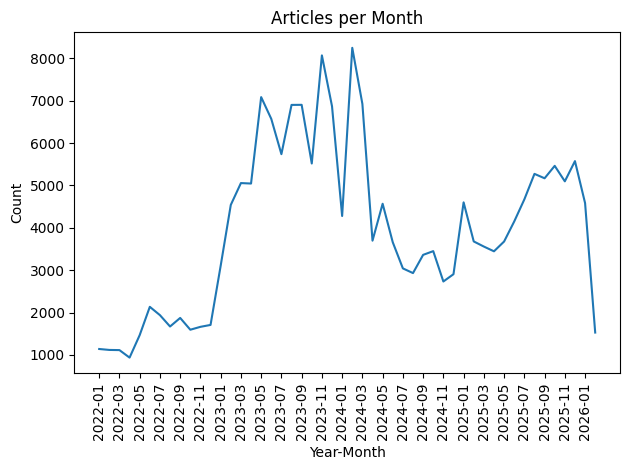

In [10]:
x = monthly.index.astype(str)
y = monthly.values

step = max(1, len(x) // 24)

plt.figure()
plt.plot(x, y)

plt.xticks(
    ticks=np.arange(0, len(x), step),
    labels=x[::step],
    rotation=90
)

plt.title("Articles per Month")
plt.xlabel("Year-Month")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## 7. Text Scale Analysis (Character Length & Token Estimate)

In [11]:
s = df["text"].fillna("")

char_len = s.str.len()

# fast token approximation
tok_est = (s.str.count(r"\s+") + 1).clip(lower=0)

df = df.assign(
    char_len=char_len,
    tok_est=tok_est
)

In [12]:
char_desc = df["char_len"].describe(
    percentiles=[.5, .75, .9, .95, .99]
)

tok_desc = df["tok_est"].describe(
    percentiles=[.5, .75, .9, .95, .99]
)

print(char_desc)
print(tok_desc)

count    199989.000000
mean       9098.766462
std        7264.733714
min          21.000000
50%        7622.000000
75%       11390.000000
90%       15766.000000
95%       19415.600000
99%       33832.040000
max      580772.000000
Name: char_len, dtype: float64
count    199989.000000
mean       1233.288746
std         963.254284
min           4.000000
50%        1035.000000
75%        1550.000000
90%        2122.000000
95%        2628.000000
99%        4595.000000
max       39966.000000
Name: tok_est, dtype: float64


### Character Length Distribution

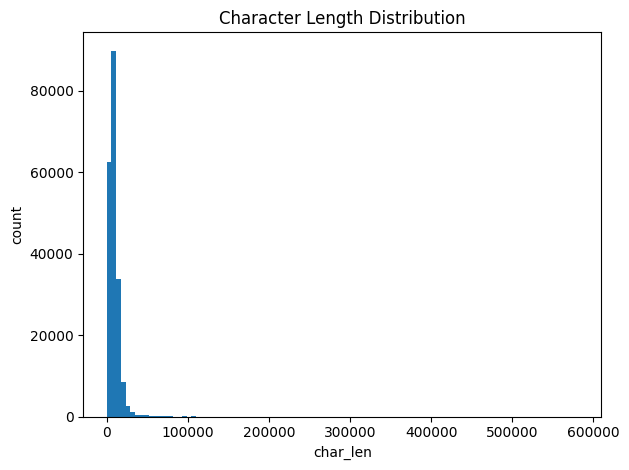

In [13]:
plt.figure()

plt.hist(
    df["char_len"].to_numpy(),
    bins=100
)

plt.title("Character Length Distribution")
plt.xlabel("char_len")
plt.ylabel("count")

plt.tight_layout()
plt.show()

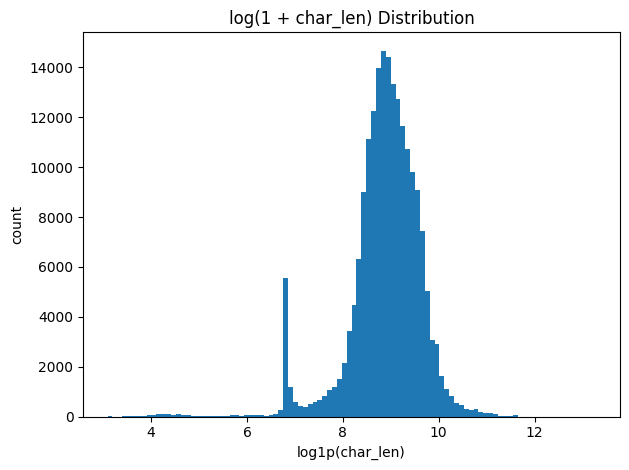

In [14]:
plt.figure()

plt.hist(
    np.log1p(df["char_len"].to_numpy()),
    bins=100
)

plt.title("log(1 + char_len) Distribution")
plt.xlabel("log1p(char_len)")
plt.ylabel("count")

plt.tight_layout()
plt.show()

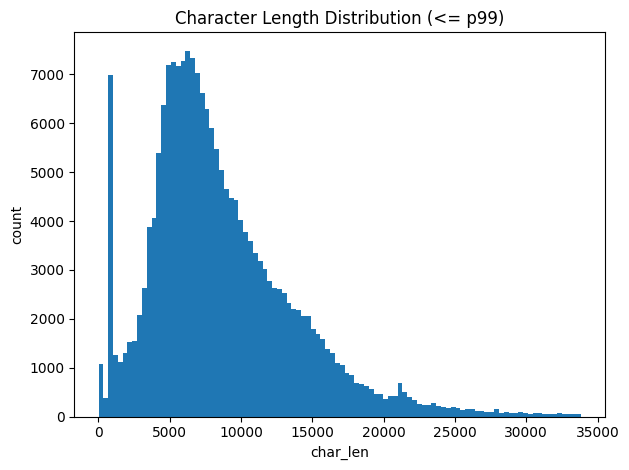

In [15]:
p99 = df["char_len"].quantile(0.99)

plt.figure()

plt.hist(
    df.loc[df["char_len"] <= p99, "char_len"].to_numpy(),
    bins=100
)

plt.title("Character Length Distribution (<= p99)")
plt.xlabel("char_len")
plt.ylabel("count")

plt.tight_layout()
plt.show()

### Token Estimate Distribution

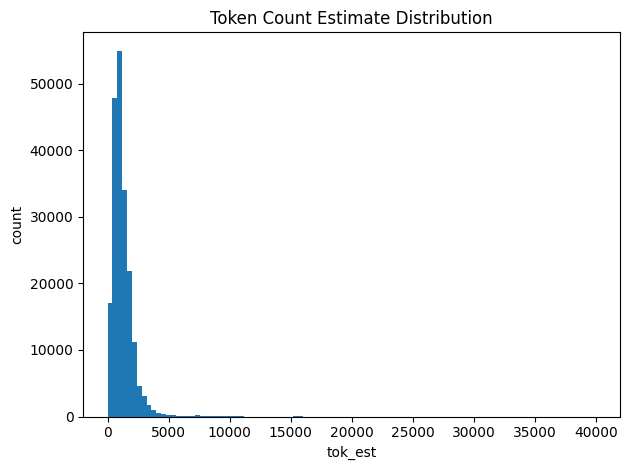

In [16]:
plt.figure()

plt.hist(
    df["tok_est"].to_numpy(),
    bins=100
)

plt.title("Token Count Estimate Distribution")
plt.xlabel("tok_est")
plt.ylabel("count")

plt.tight_layout()
plt.show()

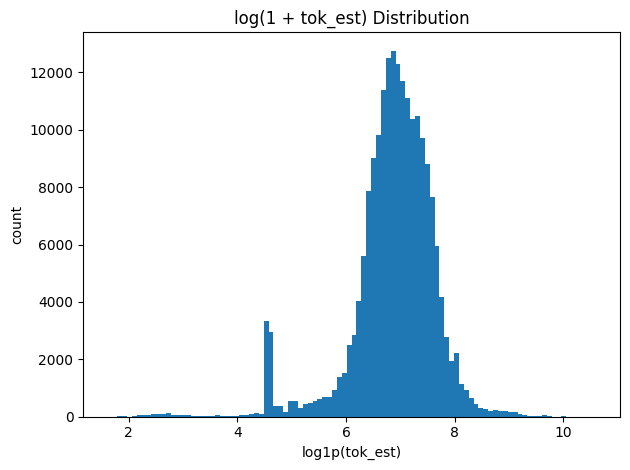

In [17]:
plt.figure()

plt.hist(
    np.log1p(df["tok_est"].to_numpy()),
    bins=100
)

plt.title("log(1 + tok_est) Distribution")
plt.xlabel("log1p(tok_est)")
plt.ylabel("count")

plt.tight_layout()
plt.show()

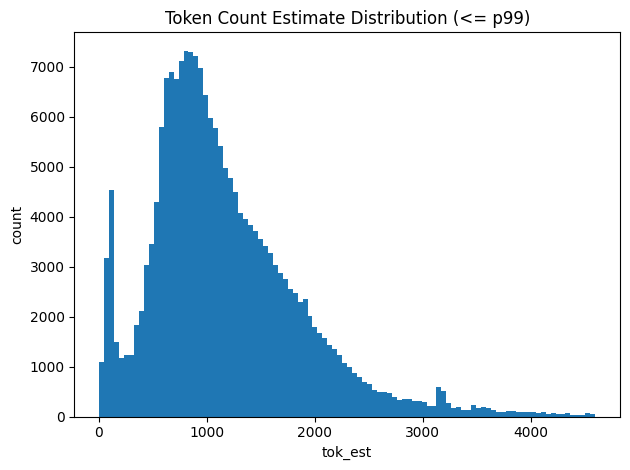

In [18]:
p99 = df["tok_est"].quantile(0.99)

plt.figure()

plt.hist(
    df.loc[df["tok_est"] <= p99, "tok_est"].to_numpy(),
    bins=100
)

plt.title("Token Count Estimate Distribution (<= p99)")
plt.xlabel("tok_est")
plt.ylabel("count")

plt.tight_layout()
plt.show()

## 8. Noise / Crawler Artifact Sampling

In [19]:
sample_random = df.sample(20, random_state=42)[["text"]]
sample_short = df.nsmallest(20, "char_len")[["text"]]
sample_long = df.nlargest(20, "char_len")[["text"]]

print("=== random ===")
print(sample_random.iloc[0, 0][:500])

print("\n=== short ===")
print(sample_short.iloc[0, 0][:500])

print("\n=== long ===")
print(sample_long.iloc[0, 0][:500])

=== random ===
  Researchers have developed an AI tool that can closely imitate your handwriting style – Cedar News English
      

Skip to contentThu. Jan 18th, 2024                         

  
HomeBreakingLebanonNewsPoliticsCrimesVideoEntertainmentAR
  
 

News
 
Researchers have developed an AI tool that can closely imitate your handwriting style
 By

Jan 16, 2024

closely, developed, handwriting, imitate, researchers, style:

   The Mohamad Bin Zayed University of Artificial Intelligence claims to be the 

=== short ===
Learning AI for Kids


=== long ===

Artificial Intelligence Software May Determine Your Next Job – NBC 7 San Diego
 

 

Skip to content
 

Main Navigation

Search

Search for:
Coronavirus
Local
Weather
Sports
Traffic
The Scene
Newsletters
Entertainment
 
Live TV


Share
Close


 
 
Trending

Tax Day
Taco Bell Fan Favorite Returning
Car Chase Ends in Hillcrest
Family Harassed in Train
Ukraine: How to Help
Live Updates: Russia Invades Ukraine


Expand
 
 

U.S. & W

## 9. Save EDA Summary

In [20]:
eda_summary = {
    "n_rows": int(len(df)),
    "n_cols": int(df.shape[1]),
    "columns": list(df.columns),
    "char_len": {k: float(v) for k, v in df["char_len"].describe(percentiles=[.5,.75,.9,.95,.99]).to_dict().items()},
    "tok_est":  {k: float(v) for k, v in df["tok_est"].describe(percentiles=[.5,.75,.9,.95,.99]).to_dict().items()},
    "date_min": str(df["dt"].min()),
    "date_max": str(df["dt"].max()),
    "date_parse_na_ratio": float(df["dt"].isna().mean()),
}

with open("eda_summary.json", "w") as f:
    json.dump(eda_summary, f, indent=2)

## 10. Parameter Decision Metrics (Cleaning / Modeling)

In [21]:
# D1: deletion ratios
for thr in [200, 400, 800, 1200]:
    print(f"min_chars<{thr}: {(df['char_len'] < thr).mean():.4%}")

min_chars<200: 0.4540%
min_chars<400: 0.5615%
min_chars<800: 0.7835%
min_chars<1200: 4.6403%


In [22]:
# D2: trimming ratios
for thr in [40000, 60000, 100000]:
    print(f"char_len>{thr}: {(df['char_len'] > thr).mean():.4%}")

char_len>40000: 0.6875%
char_len>60000: 0.2190%
char_len>100000: 0.0360%


In [23]:
# D3: token truncation ratios
for thr in [1500, 2000, 2500, 3000]:
    print(f"tok_est>{thr}: {(df['tok_est'] > thr).mean():.4%}")

tok_est>1500: 26.8915%
tok_est>2000: 12.1827%
tok_est>2500: 5.7633%
tok_est>3000: 3.5007%


In [24]:
# D4: language distribution
display(
    df["language"]
    .fillna("NA")
    .value_counts()
    .head(20)
)

language
en    199989
Name: count, dtype: int64

In [25]:
# D6: monthly distribution
display(monthly.describe())
display(monthly.tail(12))

count      50.000000
mean     3999.780000
std      1972.355696
min       937.000000
25%      2284.500000
50%      3687.000000
75%      5246.000000
max      8246.000000
dtype: float64

ym
2025-03    3557
2025-04    3445
2025-05    3676
2025-06    4149
2025-07    4670
2025-08    5272
2025-09    5168
2025-10    5461
2025-11    5096
2025-12    5573
2026-01    4583
2026-02    1528
Freq: M, dtype: int64